# **Medical Image Analysis: Brain Tumor Classification**

# Overview
This project implements a 2 stage deep learning pipeline to detect and catagorize brain tumors from MRI scans. It utilizes pytorch and TensorFlow/Keras to balance high sensitivity screening with specific diagnostic classification.


# 1. Import

In [1]:
import kagglehub
import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import tensorflow
from collections import defaultdict, Counter
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix
from PIL import Image
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator as Imgen
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [2]:
# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


In [3]:
class_counts = defaultdict(int)

for split in ['Training', 'Testing']:
    split_path = os.path.join(path, split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            class_counts[f"{split}_{class_name}"] = len(os.listdir(class_path))

class_counts

defaultdict(int,
            {'Training_pituitary': 1400,
             'Training_notumor': 1400,
             'Training_meningioma': 1400,
             'Training_glioma': 1400,
             'Testing_pituitary': 400,
             'Testing_notumor': 400,
             'Testing_meningioma': 400,
             'Testing_glioma': 400})

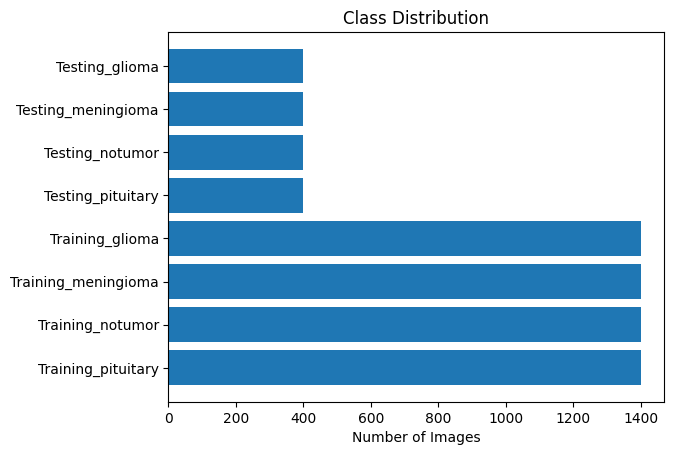

In [4]:
labels = list(class_counts.keys())
values = list(class_counts.values())

plt.figure()
plt.barh(labels, values)
plt.xlabel("Number of Images")
plt.title("Class Distribution")
plt.show()

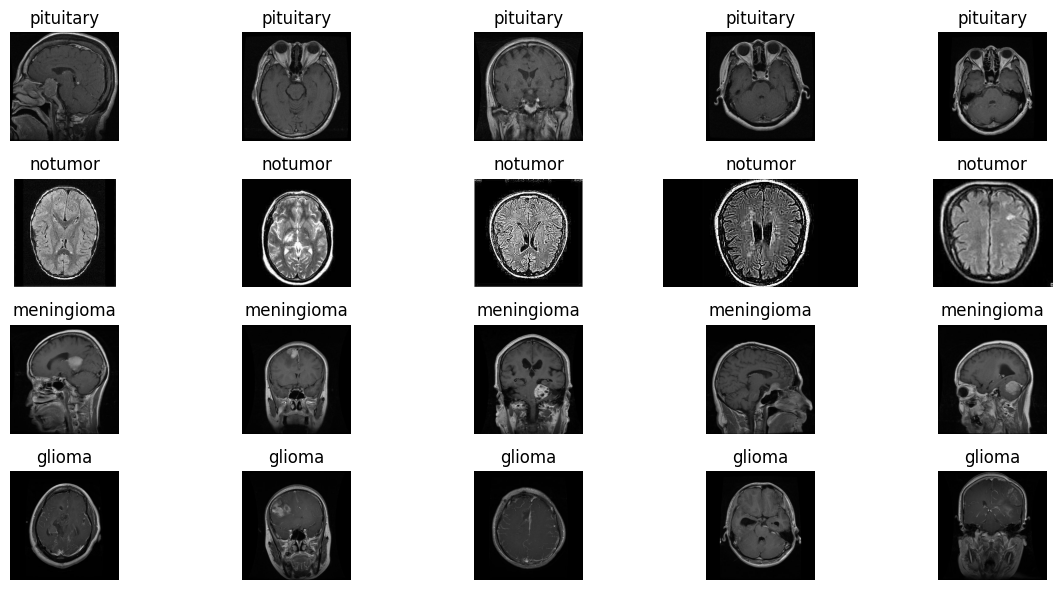

In [5]:
def show_samples(dataset_path, split='Training', num_samples=5):
    plt.figure(figsize=(12, 6))

    classes = os.listdir(os.path.join(dataset_path, split))

    for i, cls in enumerate(classes):
        class_path = os.path.join(dataset_path, split, cls)
        images = os.listdir(class_path)

        for j in range(num_samples):
            img_path = os.path.join(class_path, random.choice(images))
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(classes), num_samples, i*num_samples + j + 1)
            plt.imshow(img)
            plt.title(cls)
            plt.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(path)

In [6]:
sizes = []

for root, _, files in os.walk(path):
    for file in files:
        img_path = os.path.join(root, file)
        img = cv2.imread(img_path)
        if img is not None:
            sizes.append(img.shape[:2])  # (height, width)

sizes_df = pd.DataFrame(sizes, columns=['Height', 'Width'])

sizes_df.describe()

,Height,Width
count,7200.000000,7200.000000
mean,456.899167,453.302917
std,124.402496,130.048964
min,167.000000,150.000000
25%,449.000000,442.000000
50%,512.000000,512.000000
75%,512.000000,512.000000
max,1446.000000,1375.000000


# 2. Data Preparation

In [7]:
# Config
IMG_SIZE, BATCH_SIZE, EPOCHS, LR = 224, 32, 10, 1e-4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DATA_DIR = path

In [8]:
# Preprocessing, augmenting images
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.8, 1.2)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
# make dataset binary
def make_binary(dataset):
    notumor_idx = dataset.class_to_idx["notumor"]

    dataset.targets = [
        0 if t == notumor_idx else 1
        for t in dataset.targets
    ]

    dataset.samples = [
        (path, dataset.targets[i])
        for i, (path, _) in enumerate(dataset.samples)
    ]
    return dataset

    # Load tranformed images
def load():
    base_ds = ImageFolder(f"{DATA_DIR}/Training")
    val_size  = int(0.2 * len(base_ds))
    train_size = len(base_ds) - val_size

    # split data
    train_idx, val_idx = random_split(range(len(base_ds)),[train_size, val_size], generator=torch.Generator().manual_seed(67))
    train_full = make_binary(ImageFolder(f"{DATA_DIR}/Training", transform=train_tf))
    val_full   = make_binary(ImageFolder(f"{DATA_DIR}/Training", transform=val_tf))

    train_ds = Subset(train_full, train_idx)
    val_ds = Subset(val_full, val_idx)
    test_ds = make_binary(ImageFolder(f"{DATA_DIR}/Testing", transform=val_tf))

    print(f"\nTrain: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")


    train_labels = [label for _, label in train_ds]
    val_labels   = [label for _, label in val_ds]
    test_labels  = [label for _, label in test_ds]

    print("Train distribution:", Counter(train_labels))
    print("Val distribution:", Counter(val_labels))
    print("Test distribution:", Counter(test_labels))

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return train_loader, val_loader, test_loader


* The Data augmentation helps the model generalize to different MRI angles and positions.

In [9]:
train_loader, val_loader, test_loader = load()


Train: 4480 | Val: 1120 | Test: 1600
Train distribution: Counter({1: 3360, 0: 1120})
Val distribution: Counter({1: 840, 0: 280})
Test distribution: Counter({1: 1200, 0: 400})


# 3. Model 1 Binary classifier

In [10]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=3.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        # High gamma (3.0) aggressively penalizes confident wrong answers
        self.gamma = gamma

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        # pt is the probability of the true class
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

# Model
model1 = nn.Sequential(
    nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
    nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(256, 1)
).to(DEVICE)

optimizer = torch.optim.Adam(model1.parameters(), lr=LR)
criterion  = FocalLoss(alpha=0.75, gamma=3.0)

* FocalLoss aggressively penalizes confident wrong answers forcing model to focus on tumor edges

In [11]:
# Train
best_recall, best_precision, best_epoch = 0, 0, 0
for epoch in range(EPOCHS):
    model1.train()
    train_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.float().to(DEVICE)
        optimizer.zero_grad()

        outputs = model1(imgs).squeeze(1)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)

    model1.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    tp, fn, fp, tn = 0, 0, 0, 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs = imgs.to(DEVICE)
            labels = labels.float().to(DEVICE)

            logits = model1(imgs).squeeze(1)
            # compute val loss
            loss = criterion(logits, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.3).long()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            tp += ((preds == 1) & (labels == 1)).sum().item()
            fn += ((preds == 0) & (labels == 1)).sum().item()
            fp += ((preds == 1) & (labels == 0)).sum().item()
            tn += ((preds == 0) & (labels == 0)).sum().item()

    val_loss /= len(val_loader)
    recall = tp / (tp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # best model
    if recall > best_recall or (recall == best_recall and precision > best_precision):
        best_recall = recall
        best_precision = precision
        best_epoch = epoch + 1
        torch.save(model1.state_dict(), "best_model.pth")
    print(f"""Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}
          | Recall: {recall:.4f} | Precision: {precision:.4f} | Accuracy: {accuracy:.4f}
          | Best Recall: {best_recall:.4f} (Epoch {best_epoch})""")

Epoch 1/10 | Train Loss: 0.0362 | Val Loss: 0.0319
          | Recall: 0.9929 | Precision: 0.8089 | Accuracy: 0.8187
          | Best Recall: 0.9929 (Epoch 1)
Epoch 2/10 | Train Loss: 0.0292 | Val Loss: 0.0276
          | Recall: 0.9976 | Precision: 0.7996 | Accuracy: 0.8107
          | Best Recall: 0.9976 (Epoch 2)
Epoch 3/10 | Train Loss: 0.0248 | Val Loss: 0.0270
          | Recall: 0.9988 | Precision: 0.7783 | Accuracy: 0.7857
          | Best Recall: 0.9988 (Epoch 3)
Epoch 4/10 | Train Loss: 0.0230 | Val Loss: 0.0226
          | Recall: 0.9976 | Precision: 0.8058 | Accuracy: 0.8179
          | Best Recall: 0.9988 (Epoch 3)
Epoch 5/10 | Train Loss: 0.0219 | Val Loss: 0.0228
          | Recall: 0.9976 | Precision: 0.8089 | Accuracy: 0.8214
          | Best Recall: 0.9988 (Epoch 3)
Epoch 6/10 | Train Loss: 0.0209 | Val Loss: 0.0321
          | Recall: 0.9976 | Precision: 0.8027 | Accuracy: 0.8143
          | Best Recall: 0.9988 (Epoch 3)
Epoch 7/10 | Train Loss: 0.0200 | Val Loss: 0.

In [12]:
model1.load_state_dict(torch.load("best_model.pth"))
model1.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model1(imgs).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= .2).long()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=["No Tumor", "Tumor"]))

              precision    recall  f1-score   support

    No Tumor       1.00      0.07      0.14       280
       Tumor       0.76      1.00      0.87       840

    accuracy                           0.77      1120
   macro avg       0.88      0.54      0.50      1120
weighted avg       0.82      0.77      0.68      1120



* This Binary classifier is a PyTorch based CNN fine tuned to a threshold of 2 for safety. It Optimized for highest recall metric (**100%**) avoiding potential missed tumors. The tradeoff is plenty of false positives.

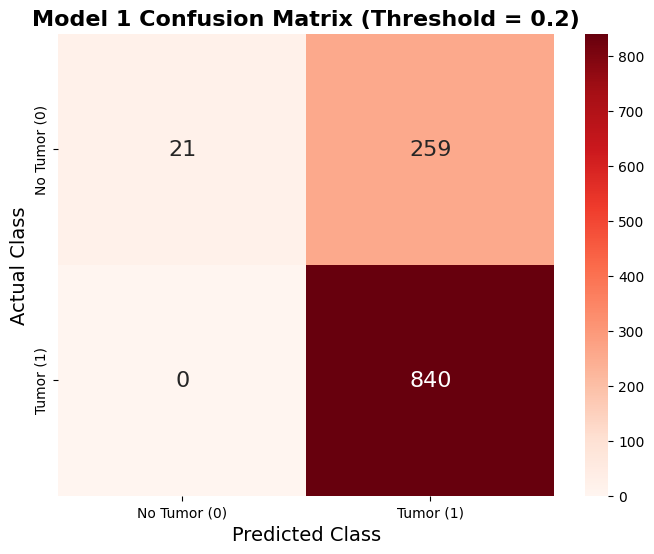

In [13]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
model1.load_state_dict(torch.load('best_model.pth'))
model1.eval()

# 1. optimal threshold
OPTIMAL_THRESHOLD = 0.2

cm_preds = []
cm_labels = []
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model1(imgs).squeeze(1)
        probs = torch.sigmoid(logits)


        preds = (probs >= OPTIMAL_THRESHOLD).long()

        cm_preds.extend(preds.cpu().numpy())
        cm_labels.extend(labels.cpu().numpy())
# 2. Compute matrix
cm = confusion_matrix(cm_labels, cm_preds)

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Tumor (0)', 'Tumor (1)'],
            yticklabels=['No Tumor (0)', 'Tumor (1)'],
            annot_kws={"size": 16})

plt.title('Model 1 Confusion Matrix (Threshold = 0.2)', fontsize=16, fontweight='bold')
plt.ylabel('Actual Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.show()

# **Part 2:** Multi-class Classifer CNN

# 3. Data Preparation

In [14]:
Classes = ['glioma', 'meningioma', 'notumor', 'pituitary']
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
train_dir = os.path.join(path, "Training")
test_dir = os.path.join(path, "Testing")

def custom_preprocessing(image):
    img_uint8 = np.array(image, dtype=np.uint8)
    img_cv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    cl1 = clahe.apply(img_cv)
    img_rgb = cv2.cvtColor(cl1, cv2.COLOR_GRAY2RGB)
    return preprocess_input(img_rgb.astype(np.float32))

traingen = Imgen(
    preprocessing_function=custom_preprocessing,
    rotation_range=10,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True,
    vertical_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)
val_gen = Imgen(preprocessing_function=custom_preprocessing, validation_split=0.2)
testgen = Imgen(preprocessing_function=custom_preprocessing)


train_generator = traingen.flow_from_directory(
    train_dir, target_size=(224, 224), batch_size=32, seed=67,
    class_mode='categorical', subset='training', classes=Classes
)

val_generator = val_gen.flow_from_directory(
    train_dir, classes=Classes, target_size=(224, 224), batch_size=32,
    seed=67, class_mode='categorical', subset='validation'
)

test_generator = testgen.flow_from_directory(
    test_dir, classes=Classes, target_size=(224, 224), batch_size=32,
    seed=67, class_mode='categorical', shuffle=False
)

print(f"Train: {train_generator.samples} | Val: {val_generator.samples} | Test: {test_generator.samples}")
print("Class index map:", train_generator.class_indices)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
Train: 4480 | Val: 1120 | Test: 1600
Class index map: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [15]:
from sklearn.utils.class_weight import compute_class_weight
raw_labels  = train_generator.classes
unique_cls  = np.unique(raw_labels)
weights     = compute_class_weight('balanced', classes=unique_cls, y=raw_labels)
class_weights = dict(zip(unique_cls.tolist(), weights.tolist()))
print("Auto class weights:", {Classes[k]: f"{v:.3f}" for k, v in class_weights.items()})

Auto class weights: {'glioma': '1.000', 'meningioma': '1.000', 'notumor': '1.000', 'pituitary': '1.000'}


# 4. Model 2

### Recommended Learning Path for Part 3

#### 1. Multi-Class CNN Modeling
*   **Kaggle: [Intro to Deep Learning](https://www.kaggle.com/learn/intro-to-deep-learning)**: Learn how to build a model, add dropout, and compile with an optimizer.
*   **Kaggle: [Computer Vision](https://www.kaggle.com/learn/computer-vision)**: Understand how `Conv2D` and `MaxPool2D` layers extract features from MRI scans.

#### 2. Visualizing with DL
*   **DeepLearning.AI: [Training History Visualization](https://www.coursera.org/articles/how-to-plot-learning-curves)**: Guide on how to use `history.history` from Keras to plot loss and accuracy.
*   **TensorBoard Guide**: [Visualizing Model Training](https://www.tensorflow.org/tensorboard/get_started): A more advanced tool for real-time visualization.

#### 3. Predicting with DL
*   **Keras Guide: [The `predict` method](https://www.tensorflow.org/api_docs/python/tf/keras/Model#predict)**: Official documentation on how to feed a single image to your model.
*   **Blog Post: [Image Classification Inference](https://towardsdatascience.com/image-classification-in-10-minutes-with-mnist-dataset-fef9c0ceef7a)**: A simple walkthrough of pre-processing an image and getting a class label back.

This part was majorly based off: https://www.kaggle.com/code/ruslankl/brain-tumor-detection-v1-0-cnn-vgg-16#4.-CNN-Model

In [16]:
import tensorflow as tf
from sklearn.utils import class_weight
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
# 1. Load the pre-trained VGG-16 base model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# 2. Freeze the base model
base_model.trainable = False

# 3. Build multi-class pipeline
model = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

# 4. Compile the model
model.compile(
    loss= tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
    optimizer= Adam(learning_rate=LR),
    metrics=['accuracy']
)
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,864,772 (56.70 MB)

 Trainable params: 149,060 (582.27 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
callbacks_phase1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model2_phase1.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]
print("Phase 1: Training classifier head (VGG16 frozen)")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    class_weight = class_weights,
    callbacks= callbacks_phase1,
    epochs=10,
    verbose=1
)

Phase 1: Training classifier head (VGG16 frozen)
Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.3043 - loss: 0.3794
Epoch 1: val_accuracy improved from None to 0.65625, saving model to best_model2_phase1.keras

Epoch 1: finished saving model to best_model2_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 96s 552ms/step - accuracy: 0.3663 - loss: 0.3057 - val_accuracy: 0.6562 - val_loss: 0.1079 - learning_rate: 1.0000e-04
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step - accuracy: 0.5261 - loss: 0.1867
Epoch 2: val_accuracy improved from 0.65625 to 0.76071, saving model to best_model2_phase1.keras

Epoch 2: finished saving model to best_model2_phase1.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 543ms/step - accuracy: 0.5368 - loss: 0.1749 - val_accuracy: 0.7607 - val_loss: 0.0720 - learning_rate: 1.0000e-04
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6106 - loss: 0.1392
Epoch 3: val_accuracy improved from 0.76071 to 0.79554, saving model to best_mod

### Fine-Tuning the Multi-class Model
To improve accuracy, we unfreeze the last convolution block of VGG16 so it can learn specific MRI features.

In [18]:
# 1. Unfreeze the base model
base_model.trainable = True

# 2. Re-freeze everything EXCEPT the last block (block5)
for layer in base_model.layers[:-8]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable VGG16 layers: {trainable_count}/{len(base_model.layers)}")
# 3. Re-compile with a much lower learning rate (standard for fine-tuning)
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalFocalCrossentropy(alpha=0.25, gamma=2.0),
    metrics=['accuracy']
)
callbacks_phase2 = [
    EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model2_vgg16.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]
# 4. Fine-tune for a few more epochs
fine_tune_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight= class_weights,
    callbacks= callbacks_phase2,
    verbose=1
)

Trainable VGG16 layers: 8/19
Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 536ms/step - accuracy: 0.7992 - loss: 0.0564
Epoch 1: val_accuracy improved from None to 0.85714, saving model to best_model2_vgg16.keras

Epoch 1: finished saving model to best_model2_vgg16.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 101s 596ms/step - accuracy: 0.8025 - loss: 0.0580 - val_accuracy: 0.8571 - val_loss: 0.0471 - learning_rate: 1.0000e-05
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.8342 - loss: 0.0457
Epoch 2: val_accuracy improved from 0.85714 to 0.89286, saving model to best_model2_vgg16.keras

Epoch 2: finished saving model to best_model2_vgg16.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 591ms/step - accuracy: 0.8426 - loss: 0.0436 - val_accuracy: 0.8929 - val_loss: 0.0329 - learning_rate: 1.0000e-05
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.8542 - loss: 0.0424
Epoch 3: val_accuracy did not improve from 0.89286
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 583ms/step - accuracy:

# 5. Explanatory Data Analysis

In [19]:
test_generator.reset()
preds     = model.predict(test_generator, verbose=1)
y_pred    = np.argmax(preds, axis=1)
y_true    = test_generator.classes
cls_names = list(test_generator.class_indices.keys())

print("Model 2 (VGG16) — Test Classification Report")
print(classification_report(y_true, y_pred, target_names=cls_names))

test_loss, test_acc = model.evaluate(test_generator, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 186ms/step
Model 2 (VGG16) — Test Classification Report
              precision    recall  f1-score   support

      glioma       0.90      0.77      0.83       400
  meningioma       0.84      0.69      0.76       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.87      0.99      0.92       400

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600

Test Loss: 0.0500 | Test Accuracy: 0.8606


* This multi class classifier uses TensorFlow/Keras with transfer learning(VGG16). It categorizes detected tumors into 3 types Glioma, Meningioma, and Pituitary while also proving a second check for No tumor that leaked from model 1.

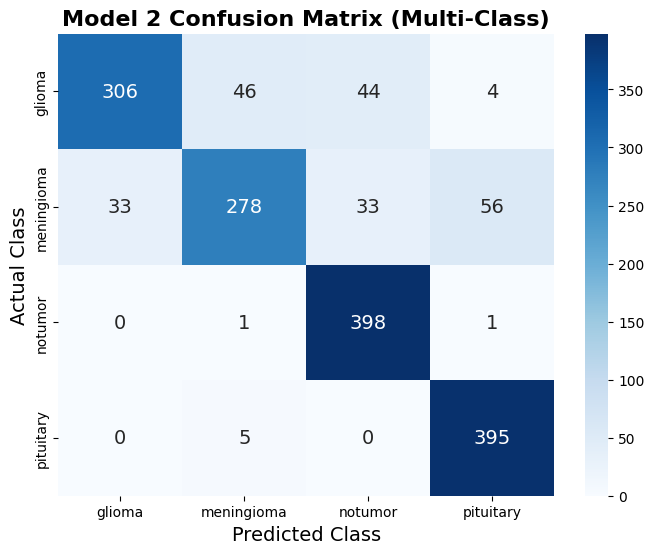

In [20]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cls_names,
            yticklabels=cls_names,
            annot_kws={"size": 14})

plt.title('Model 2 Confusion Matrix (Multi-Class)', fontsize=16, fontweight='bold')
plt.ylabel('Actual Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)
plt.show()

### What is Visualizing with DL?
In Deep Learning, visualization helps us 'peek inside the black box'. It usually involves:
* **Training History**: Plotting the loss and accuracy curves for both training and validation sets. If the training accuracy goes up but validation goes down, you have 'overfitting'.
* **Feature Maps**: Visualizing what the convolutional layers see (e.g., edges, textures, or shapes).
* **Confusion Matrix**: A table showing exactly which classes the model is confusing (e.g., is it mistaking Pituitary tumors for Gliomas?).

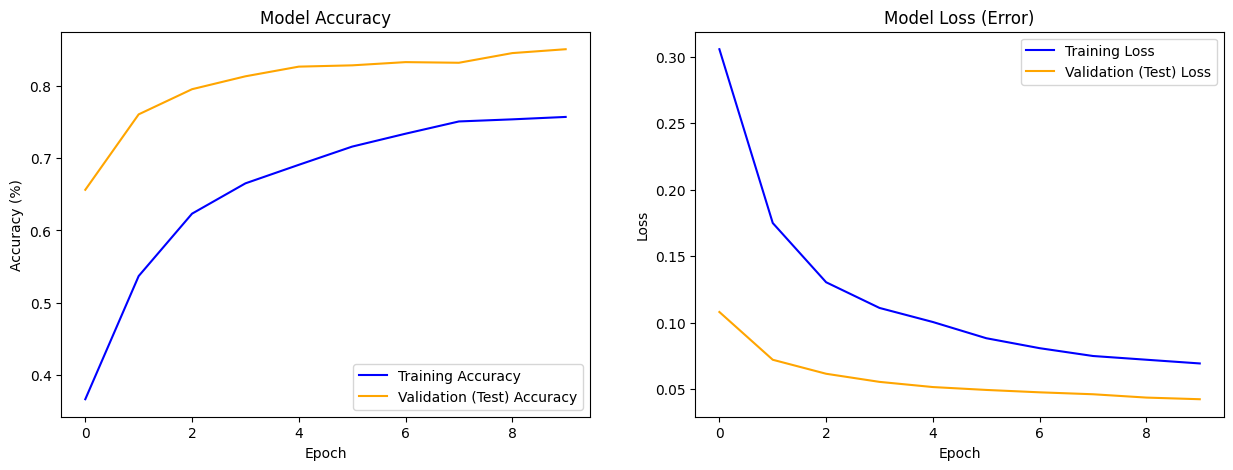

In [21]:
# Create a figure with two subplots (Accuracy and Loss)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Accuracy
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation (Test) Accuracy', color='orange')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend()

# Plot Loss
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation (Test) Loss', color='orange')
ax2.set_title('Model Loss (Error)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()

plt.show()

## Prediction pipeline

In [22]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
model1.load_state_dict(torch.load('best_model.pth'))
model1.eval()
model = keras.models.load_model('best_model2_vgg16.keras')

KERAS_CLASSES = {i: c for i, c in enumerate(Classes)}

def crop_brain_contour(image, margin=15):
    # Convert PIL to cv2 grayscale
    img_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)

    # Threshold to find the brain/skull
    _, thresh = cv2.threshold(img_cv, 45, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        # Find the largest contour (the brain)
        c = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)

        img_h, img_w = img_cv.shape
        x_min = max(0, x - margin)
        y_min = max(0, y - margin)
        x_max = min(img_w, x + w + margin)
        y_max = min(img_h, y + h + margin)

        # Crop the original image
        image_arr = np.array(image)
        cropped_img = image_arr[y_min:y_max, x_min:x_max]
        return Image.fromarray(cropped_img)
    return image

def predict_pipeline(image):
    cropped_image = crop_brain_contour(image)
    # Model 1 (PyTorch Binary Filter)
    img1 = val_tf(cropped_image).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model1(img1)).item()

    # 🟢 No Tumor (Model 1 confidence)
    if prob < OPTIMAL_THRESHOLD:
        return {
            "prediction": "No Tumor",
            "confidence": round(1 - prob, 2),
            "stage": "Model 1 filtering"
        }

    img2 = np.array(cropped_image)
    img2 = cv2.resize(img2, (IMG_SIZE, IMG_SIZE))
    img2 = vgg_preprocess(img2.astype(np.float32))

    img3 = np.expand_dims(img2, axis=0)

    probs2 = model.predict(img3, verbose=0).squeeze()
    conf = float(np.max(probs2))

    pred = KERAS_CLASSES[int(np.argmax(probs2))]
    entropy     = float(-np.sum(probs2 * np.log(probs2 + 1e-8)))
    max_entropy = np.log(4)  # uniform over 3 classes


    # 🟡 OOD Gate: Uncertain (Logic maintained for Doctor Review)
    if conf < 0.45 or entropy > 0.85 * max_entropy:
        return {
           "prediction": "Uncertain → Doctor Review",
            "confidence": round(conf, 2),
            "stage": "Model 2 Uncertainty OOD gate",
            "entropy":    round(entropy, 4),
            "top_class":  pred
        }
    # 🔴 Tumor suspected → Verify and Classify with Model 2
    elif conf < 0.85:
        return {
        "prediction": f" {pred} suspected → Doctor Review",
        "confidence": round(conf, 2),
        "stage": "Model 2 low confidence gate",
        "class_probs": {KERAS_CLASSES[i]: round(float(p), 4) for i, p in enumerate(probs2)}
       }

    return {
        "prediction": pred,
        "confidence": round(conf, 2),
        "stage": "Final Classification",
        "class_probs": {KERAS_CLASSES[i]: round(float(p), 4) for i, p in enumerate(probs2)}
    }

* Integrated pipeline that includes brain contour cropping, an Out-of-Distribution (OOD) uncertainty gate (using entropy), and a "Doctor Review" trigger for low-confidence predictions.
* Brain contour cropping uses OpenCV to remove non brain pixels.
* OOD makes it where if models entropy to too high(confused) it defaults to a doctor for review

# 7. Testing

In [23]:
all_test_images = [
    os.path.join(root, f)
    for root, _, files in os.walk(test_dir)
    for f in files if f.lower().endswith(('jpg', 'jpeg', 'png'))
]

random.seed(67)
sample = random.sample(all_test_images, min(50, len(all_test_images)))

stage_counts = defaultdict(int)
for img_path in sample:
    img_pil = Image.open(img_path).convert('RGB')
    result  = predict_pipeline(img_pil)
    stage_counts[result['stage']] += 1
    print(f"{os.path.basename(os.path.dirname(img_path)):12s} → {result['prediction']:50s} | conf={result['confidence']:.3f}")

print("\nStage routing summary:", dict(stage_counts))

pituitary    → pituitary                                          | conf=0.870
pituitary    → pituitary                                          | conf=0.930
glioma       →  glioma suspected → Doctor Review                  | conf=0.830
meningioma   →  meningioma suspected → Doctor Review              | conf=0.480
meningioma   →  meningioma suspected → Doctor Review              | conf=0.720
meningioma   →  pituitary suspected → Doctor Review               | conf=0.720
notumor      → notumor                                            | conf=0.960
glioma       → Uncertain → Doctor Review                          | conf=0.380
meningioma   → Uncertain → Doctor Review                          | conf=0.380
meningioma   →  meningioma suspected → Doctor Review              | conf=0.550
glioma       →  meningioma suspected → Doctor Review              | conf=0.540
notumor      → notumor                                            | conf=0.960
notumor      → notumor                              

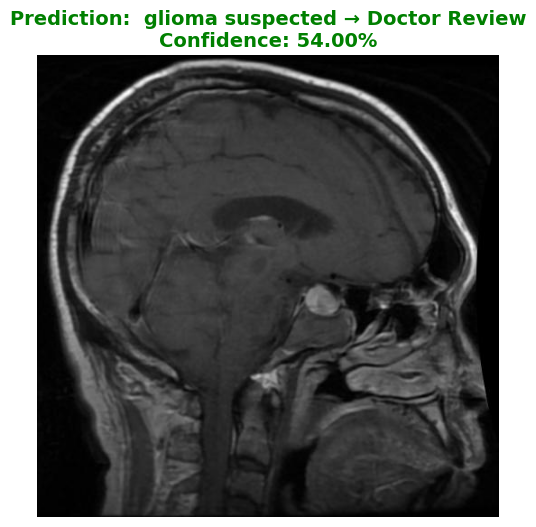

Full Pipeline Metadata:
Prediction:  glioma suspected → Doctor Review
Confidence: 0.54
Stage: Model 2 low confidence gate
Class_probs: {'glioma': 0.5373, 'meningioma': 0.2303, 'notumor': 0.0133, 'pituitary': 0.219}


In [24]:
test_image_path = all_test_images[0]

def test_single_image(image_path):
    # Load and show image
    img_pil = Image.open(image_path).convert('RGB')

    # Get results from our pipeline
    result = predict_pipeline(img_pil)

    # Plotting
    plt.figure(figsize=(6, 6))
    plt.imshow(img_pil)
    plt.axis('off')

    title_color = 'red' if 'Tumor' in result['prediction'] and 'No' not in result['prediction'] else 'green'
    if 'Uncertain' in result['prediction']: title_color = 'orange'

    plt.title(f"Prediction: {result['prediction']}\nConfidence: {result['confidence']:.2%}",
              fontsize=14, color=title_color, fontweight='bold')
    plt.show()

    print("Full Pipeline Metadata:")
    for k, v in result.items():
        print(f"{k.capitalize()}: {v}")

test_single_image(test_image_path)

In [25]:
correct = 0
total = len(sample)

for img_path in sample:
    # 1. Get the actual label from the folder name
    actual_label = os.path.basename(os.path.dirname(img_path))

    # 2. Get the prediction from your pipeline
    img_pil = Image.open(img_path).convert('RGB')
    result = predict_pipeline(img_pil)
    pred_label = result['prediction'].strip().lower()

    # 3. Check if it matches (handling the "suspected" and "doctor review" strings)
    # We check if the actual label is contained within the prediction string
    if actual_label in pred_label:
        correct += 1

accuracy = (correct / total) * 100
print(f"Batch Accuracy: {accuracy:.2f}% ({correct}/{total} correct)")

Batch Accuracy: 70.00% (35/50 correct)


### Detailed Pipeline Evaluation

The previous batch accuracy calculation for the pipeline was somewhat misleading, as it treated cases flagged for 'Doctor Review' as incorrect. Below, I'll provide a more nuanced evaluation that categorizes predictions into:

*   **Definitive Correct:** The pipeline made a confident and correct classification (either 'No Tumor' or a specific tumor type).
*   **Definitive Incorrect:** The pipeline made a confident but incorrect classification.
*   **Correctly Flagged for Review (Tumor):** The pipeline identified an actual tumor but flagged it for review due to uncertainty or low confidence. This is a desirable safety outcome.
*   **Correctly Flagged for Review (No Tumor):** The pipeline flagged an actual 'no tumor' case for review. While Model 1 aims to filter these, Model 2's gates might catch some as uncertain. This is also a safe outcome.

This breakdown gives a more comprehensive understanding of the pipeline's performance, balancing accuracy with safety.

In [28]:
definitive_correct = 0
definitive_incorrect = 0
tumor_flagged_for_review = 0
notumor_flagged_for_review = 0

total_samples = len(sample)

for img_path in sample:
    actual_label = os.path.basename(os.path.dirname(img_path))
    img_pil = Image.open(img_path).convert('RGB')
    result = predict_pipeline(img_pil)
    predicted_category = result['prediction']
    stage = result['stage']

    is_actual_tumor = (actual_label != 'notumor')

    if stage == "Final Classification" or stage == "Model 1 filtering":
        # Definitive classifications
        if (predicted_category.lower() == actual_label.lower()) or \
           (predicted_category == "No Tumor" and actual_label == "notumor"):
            definitive_correct += 1
        else:
            definitive_incorrect += 1
    elif stage == "Model 2 Uncertainty OOD gate" or stage == "Model 2 low confidence gate":
        # Cases flagged for doctor review
        if is_actual_tumor:
            tumor_flagged_for_review += 1
        else:
            notumor_flagged_for_review += 1

print(f"--- Detailed Pipeline Performance on {total_samples} Samples ---")
print(f"Definitive Correct Classifications: {definitive_correct}")
print(f"Definitive Incorrect Classifications: {definitive_incorrect}")
print(f"Actual Tumors Flagged for Review: {tumor_flagged_for_review}")
print(f"Actual No Tumors Flagged for Review: {notumor_flagged_for_review}")

# Calculate percentages
percent_definitive_correct = (definitive_correct / total_samples) * 100
percent_definitive_incorrect = (definitive_incorrect / total_samples) * 100
percent_tumor_flagged = (tumor_flagged_for_review / total_samples) * 100
percent_notumor_flagged = (notumor_flagged_for_review / total_samples) * 100

print(f"\nPercentage Definitive Correct: {percent_definitive_correct:.2f}%")
print(f"Percentage Definitive Incorrect: {percent_definitive_incorrect:.2f}%")
print(f"Percentage Actual Tumors Flagged for Review: {percent_tumor_flagged:.2f}%")
print(f"Percentage Actual No Tumors Flagged for Review: {percent_notumor_flagged:.2f}%")

# Combined metrics
total_reviewed = tumor_flagged_for_review + notumor_flagged_for_review
percent_total_reviewed = (total_reviewed / total_samples) * 100
print(f"\nTotal Cases Sent for Doctor Review: {total_reviewed} ({percent_total_reviewed:.2f}%)")

# Effective accuracy considering reviews as a form of correct handling of uncertainty
effective_correct_or_reviewed = definitive_correct + total_reviewed
percent_effective_correct_or_reviewed = (effective_correct_or_reviewed / total_samples) * 100
print(f"Effective Correct (including reviewed cases): {percent_effective_correct_or_reviewed:.2f}%")


--- Detailed Pipeline Performance on 50 Samples ---
Definitive Correct Classifications: 19
Definitive Incorrect Classifications: 2
Actual Tumors Flagged for Review: 28
Actual No Tumors Flagged for Review: 1

Percentage Definitive Correct: 38.00%
Percentage Definitive Incorrect: 4.00%
Percentage Actual Tumors Flagged for Review: 56.00%
Percentage Actual No Tumors Flagged for Review: 2.00%

Total Cases Sent for Doctor Review: 29 (58.00%)
Effective Correct (including reviewed cases): 96.00%


In [27]:
# Save both versions so the System Architect has options
model.save('multiclass_tumor_model.h5')
model.save('multiclass_tumor_model.keras')
print("Both model formats successfully saved! Handoff ready.")

Both model formats successfully saved! Handoff ready.


# 8. Conclusion

* Model 1 is a binary classifier that was used to extract all tumors
* Model 2 is a multi classifier that identified types of tumor and filterd out any leaked no tumors from model 2
* This projects biggest bottleneck was optimizing model 2. There were dozens attempts to get over 85% F1 score on the 3 tumor classes. After plenty of debugging/optimizing we decided to include the 4th class 'no tumor' as a classifier. Previously it was believed to be the main issue for model 2 metrics, when the no tumor images leak in due to low precision from the 1st model that caused predictions to performing mediocre.
* After including it into model 2 and checking the metrics a insight that kept reccuring was that the model kept confusing Glioma & Meningioma with each other. Knowing this allowed us to accept the model for its imperfections.
* Overall the models performs well, model 1 having a recall of **100%** catching all tumors, and model 2 Identifing missed no tumors from model 1 and the types of tumors with **83%** accuracy.